# Portfolio: Mario Casanova — Data Science & Analytics
## Synthesis — Cross-Archetype Comparative Dynamics: San Francisco, Seattle, Houston, and Washington DC Through Three Cycles

---

### Grounding and provenance, and a naming note
This notebook is the join across the three per-archetype temporal notebooks in this same
directory: `archetype_a_unaffordable_dynamics.ipynb` (San Francisco + Seattle), `archetype_b_affordable_dynamics.ipynb`
(Houston), and `archetype_c_median_dynamics.ipynb` (Washington DC). Those three notebooks selected
their metros by an affordability/volatility rule run in `us_housing_archetypes.ipynb`, then each
independently recomputed HAI, drawdown, recovery time, and rolling volatility for its own archetype
against the 2008 GFC, 2020 COVID, and 2022+ rate-shock cycles. This notebook is deliberately named
`cross_archetype_dynamics.ipynb`, not `03_cross_archetype_dynamics.ipynb` as an earlier plan draft
proposed — the task board is one step removed from the actual repo layout; there is no
`us_housing_dynamics/` project, everything lives in
`Portfolio-repo/01_professional/real_estate/notebooks/`, and the un-prefixed, descriptive name is
consistent with how its three siblings are already named.

A second mapping note, since the originating task description used generic labels
("unaffordable / typical / affordable") that do not match the archetype letters used inside the
notebooks themselves: **Archetype A = San Francisco + Seattle (unaffordable, volatile)**,
**Archetype B = Houston (affordable, historically stable)**, **Archetype C = Washington DC
(near-median affordability)**. So the task's "unaffordable / typical / affordable" trio maps onto
**A / C / B** respectively, not A/B/C in that order — DC is the "typical" case, Houston the
"affordable" one.

**This is a real join, not a hand-copy.** Every comparative number below (drawdown depths, recovery
months, volatility levels, HAI trajectories) is recomputed here from the same source CSVs in
`../data/real/` using the same HAI/drawdown/recovery/volatility definitions as the three sibling
notebooks — it does not re-read their notebook outputs. Where a number below disagrees with a
sibling's headline figure, that disagreement is reported plainly in §4/§5, not silently reconciled.
Nothing is written back into `../data/real/`; figures go to `./figures/` with a `cross_` prefix so
this notebook cannot collide with or overwrite a sibling's own figure files.

## 1. The real question

Each per-archetype notebook already established that its own metro(s) behaved a certain way through
three cycles, taken one archetype at a time. The comparative question those notebooks could not ask,
because each only looked at its own metro, is: **does the archetype label predict the dynamics, or
only the level?** Concretely: does "affordable" (Houston) mean "shock-resistant" in *every* cycle, or
only in the cycle it happened to be tested against first (2008)? Is the "near-median" case (DC)
actually mid-pack in amplitude and recovery time, or does it have its own outlier tail the label
hides? And does the "unaffordable, volatile" label (SF/Seattle) hold up as a description of realized
volatility in all three cycles, or does it concentrate unevenly? Affordability *selected* these four
metros in the parent notebook — it did not select their dynamics. The contrast in boom-bust
amplitude, recovery time, and volatility regime across cycles is a finding to be read off the joined
data, not an assumption carried over from the archetype labels.

## 2. Why this matters, and to whom

A single archetype label ("affordable and stable") collapses three separate cyclical episodes into
one adjective. That is a real loss of information for anyone who has to act cycle-by-cycle rather
than on an average:

- **Lenders and mortgage insurers** pricing risk in 2026 need to know whether "Houston is stable" is a
  claim about *all* shocks or only about the housing-price shock in 2008 specifically — a market can
  be price-stable and affordability-fragile at the same time, which changes loss-severity assumptions
  for a rate-driven affordability crunch differently than for a price crash.
- **Buyers** choosing between a "safe" affordable metro and a "risky" coastal one are implicitly
  betting that *last cycle's* pattern repeats; if the ranking of which archetype gets hit hardest
  flips between cycles, that bet is worse than it looks.
- **Policymakers** benchmarking "typical" market conditions (DC, Archetype C) against the extremes need
  to know whether "typical" also means "moderate dynamics," or whether the median-affordability metro
  can still carry an outlier tail in one dimension (e.g., GFC drawdown depth or recovery time) even
  while sitting in the middle of the affordability distribution.

## 3. Where the data bends, and where it breaks

This inherits every data-limit disclosure from the three sibling notebooks (repeated here because
this notebook stands on its own), plus limits specific to comparing four metros at once:

1. **Zillow ZHVI (2000–2026, monthly, seasonally adjusted)** is the primary series for all four
   metros and is the only series with enough temporal resolution to locate cycle-level peaks/troughs
   and a rolling volatility regime. It cannot see anything before 2000, so the "long-run sanity check"
   each archetype used (FHFA, quarterly, back to the 1970s-80s) is not repeated in full here; this
   notebook is scoped to the three declared cycles, all of which fall inside Zillow's window.
2. **Income data (Census SAIPE via FRED) stops in 2024** for county-level series; 2025–2026 values are
   linearly extrapolated from each county's trailing 3-year CAGR, exactly as in the per-archetype
   notebooks. This affects the still-unresolved 2022+ cycle's affordability read disproportionately.
3. **HAI is a single, shared amortization assumption (80% LTV, 25% DTI for P&I, 30-year fixed)** across
   all four metros — a uniform lens applied to genuinely different local mortgage markets (down
   payment norms, property-tax loads, insurance costs, which the P&I-only HAI does not include at
   all). Comparing HAI *levels* across metros compares apples of the same recipe, not apples of the
   same actual household experience in each city.
4. **MSA re-delineation over the 2000–2026 window is not modeled.** OMB periodically redraws MSA
   boundaries (e.g., county additions/removals); Zillow's and FRED's metro definitions are taken as
   given at whatever vintage each provider currently uses, and this notebook does not attempt to
   reconstruct a fixed-boundary panel back to 2000. A metro's 2026 boundary is not guaranteed to be
   its 2000 boundary.
5. **n = 4 metros.** This notebook makes no claim that four cities are a representative or
   statistically powered sample of "affordable" vs. "unaffordable" housing markets in general. Any
   contrast described below is illustrative of these four specific metros' histories, not an inference
   about affordability-as-a-cause-of-stability across the U.S. metro population. A correlation
   observed across n=4 points is not evidence of a causal mechanism.
6. **Price-index-only.** As in every sibling notebook, "recovery" means the price index returned to
   its prior nominal peak — not that transaction volume, days-on-market, or inventory recovered
   alongside it, and not adjusted for inflation.

## 4. Method, and the assumption checks I actually ran

**Metros and roles**, as selected by `us_housing_archetypes.ipynb` and inherited unchanged from the
three sibling notebooks:

| Archetype | Metro(s) | Role in this comparison |
|---|---|---|
| A | San Francisco, CA / Seattle, WA | unaffordable, high-volatility anchor |
| B | Houston, TX | affordable, historically-stable anchor |
| C | Washington, DC | near-median affordability, the "typical" case |

**Cycle windows** — the union of the windows each sibling notebook declared, harmonized to one shared
set so all four metros are read against identical calendar boundaries (the archetype notebooks each
used slightly different window starts/ends tuned to their own metro's context; here I standardize so
cross-metro comparison is on equal footing, which is itself a declared analytical choice, not a
re-derivation of "the" correct window):
- **2008 GFC**: peak search 2006-01 to 2009-12, trough search extended to 2012-12.
- **2020 COVID**: peak search 2019-06 to 2020-12, trough search extended to 2021-12.
- **2022+ rate shock**: peak search 2021-06 to 2023-06, trough search extended through 2026 (end of
  series) — may not have a resolved trough/recovery; reported as such where true.

**Drawdown** = (trough price − cycle peak price) / cycle peak price, running peak located inside the
declared window only (peak-then-trough, not a floating running-max across the whole series, so all
four metros are read against the same window logic). **Recovery time** = months from trough to the
first date price ≥ that cycle's peak (nominal); "not yet recovered" is reported plainly, not imputed.
**Volatility regime** = rolling 24-month SD of YoY price returns, plotted through calendar time.
**HAI** = median-household-income / qualifying-income × 100, same 80% LTV / 25% DTI / 30yr assumption
used in every sibling notebook.

**Assumption checks executed, not assumed**: ADF (stationarity) and Ljung-Box (lag-12 serial
correlation) on each metro's own YoY return series, run independently here rather than imported from
the sibling notebooks, since the comparative volatility claim below is only defensible if it rests on
the same statistical footing for all four metros at once.

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox

p = Path.cwd()
for _ in range(6):
    if (p / "portfolio_style.py").exists():
        sys.path.insert(0, str(p))
        break
    p = p.parent

try:
    import portfolio_style
    print("Applied Mario Casanova's design tokens successfully.")
except ImportError:
    print("Could not import portfolio_style. Falling back to defaults.")
    sns.set_theme(style='whitegrid')

DATA_DIR = '../data/real'
FIG_DIR = './figures'
os.makedirs(FIG_DIR, exist_ok=True)
print(f"Data directory: {os.path.abspath(DATA_DIR)}")
print(f"Figures directory: {os.path.abspath(FIG_DIR)}")

Applied Mario Casanova's design tokens successfully.
Data directory: /Users/mariocasanova10pa/Documents/Portfolio/Portfolio-repo/01_professional/real_estate/data/real
Figures directory: /Users/mariocasanova10pa/Documents/Portfolio/Portfolio-repo/01_professional/real_estate/notebooks/figures


In [2]:
def load_clean_fred_series(filepath):
    df = pd.read_csv(filepath)
    date_col = 'observation_date' if 'observation_date' in df.columns else 'DATE'
    df = df.rename(columns={date_col: 'DATE'})
    df['DATE'] = pd.to_datetime(df['DATE'])
    val_cols = [c for c in df.columns if c != 'DATE']
    if val_cols:
        df = df.rename(columns={val_cols[0]: 'value'})
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    df = df.dropna()
    return df

df_zillow = pd.read_csv(os.path.join(DATA_DIR, 'Metro_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv'))
cols_date = [c for c in df_zillow.columns if c.startswith('20')]
dates_z = pd.to_datetime(cols_date) + pd.offsets.MonthEnd(0)

def zillow_series(metro_prefix):
    row = df_zillow[df_zillow['RegionName'].str.startswith(metro_prefix, na=False)]
    assert not row.empty, f"metro not found: {metro_prefix}"
    vals = row[cols_date].iloc[0].values
    return pd.DataFrame({'DATE': dates_z, 'Price': vals}).astype({'Price': float})

df_mort_raw = load_clean_fred_series(os.path.join(DATA_DIR, 'MORTGAGE30US.csv'))
df_mort = df_mort_raw.set_index('DATE').resample('ME').mean().reset_index().rename(columns={'value': 'MortgageRate'})

def load_income(fname):
    df = load_clean_fred_series(os.path.join(DATA_DIR, fname))
    df = df.set_index('DATE').resample('YE').mean().reset_index()
    val3 = df.iloc[-4]['value']
    growth = (df.iloc[-1]['value'] / val3) ** (1 / 3) - 1
    cur_date, cur_val = df.iloc[-1]['DATE'], df.iloc[-1]['value']
    extra = []
    while cur_date.year < 2026:
        cur_date = cur_date + pd.offsets.DateOffset(years=1)
        cur_val = cur_val * (1 + growth)
        extra.append({'DATE': cur_date, 'value': cur_val})
    if extra:
        df = pd.concat([df, pd.DataFrame(extra)], ignore_index=True)
    all_months = pd.date_range(df['DATE'].min(), df['DATE'].max(), freq='ME')
    m = pd.DataFrame(index=all_months).join(df.set_index('DATE')[['value']], how='left')
    m['value'] = m['value'].interpolate(method='linear')
    return m.reset_index().rename(columns={'index': 'DATE', 'value': 'Income'}), growth

def build_hai(price_df, income_df, mort_df):
    m = pd.merge(price_df, mort_df, on='DATE', how='inner')
    m = pd.merge(m, income_df, on='DATE', how='inner')
    m['r'] = m['MortgageRate'] / 100 / 12
    m['LoanAmount'] = m['Price'] * 0.80
    m['MonthlyPI'] = m['LoanAmount'] * (m['r'] * (1 + m['r'])**360) / ((1 + m['r'])**360 - 1)
    m['QualifyingIncome'] = m['MonthlyPI'] * 4 * 12
    m['HAI'] = (m['Income'] / m['QualifyingIncome']) * 100
    m['Price_YoY_Return'] = m['Price'].pct_change(12)
    return m

METROS = {
    'San Francisco': dict(zillow_prefix='San Francisco, CA', income_file='MHI_San_Francisco_CA.csv', archetype='A', color='oxblood'),
    'Seattle':        dict(zillow_prefix='Seattle, WA',       income_file='MHI_Seattle_WA.csv',        archetype='A', color='oxblood_2'),
    'Houston':        dict(zillow_prefix='Houston, TX',       income_file='MHI_Houston_TX.csv',        archetype='B', color='forest'),
    'Washington DC':  dict(zillow_prefix='Washington, DC',    income_file='MHI_Washington_DC.csv',     archetype='C', color='ochre'),
}

panel = {}
for name, spec in METROS.items():
    price = zillow_series(spec['zillow_prefix'])
    income, growth = load_income(spec['income_file'])
    df = build_hai(price, income, df_mort)
    panel[name] = df
    print(f"{name:15s} (Archetype {spec['archetype']}): Zillow {df['DATE'].min():%Y-%m} to {df['DATE'].max():%Y-%m}, "
          f"n={len(df)}, trailing-3yr income CAGR used for 2025-26 projection: {growth:.2%}")

San Francisco   (Archetype A): Zillow 2000-01 to 2026-05, n=317, trailing-3yr income CAGR used for 2025-26 projection: 4.63%
Seattle         (Archetype A): Zillow 2000-01 to 2026-05, n=317, trailing-3yr income CAGR used for 2025-26 projection: 3.40%
Houston         (Archetype B): Zillow 2000-01 to 2026-05, n=317, trailing-3yr income CAGR used for 2025-26 projection: 5.53%
Washington DC   (Archetype C): Zillow 2000-01 to 2026-05, n=317, trailing-3yr income CAGR used for 2025-26 projection: 6.27%


### Assumption checks — stationarity and serial correlation of YoY returns, all four metros

Standard deviation as a volatility metric presumes the returns series is approximately stationary;
otherwise "volatility" is confounded with trend. Run independently here for all four metros, not
imported from the sibling notebooks.

In [3]:
print("--- ADF (stationarity) and Ljung-Box (lag-12 serial correlation) on YoY returns ---")
adf_results = {}
for name, df in panel.items():
    ret = df['Price_YoY_Return'].dropna()
    adf_res = adfuller(ret, autolag='AIC')
    lb_res = acorr_ljungbox(ret, lags=[12], return_df=True)
    lb_stat, lb_p = lb_res.loc[12, 'lb_stat'], lb_res.loc[12, 'lb_pvalue']
    adf_results[name] = adf_res[1]
    print(f"{name:15s} ADF stat={adf_res[0]:7.3f} p={adf_res[1]:.4e} -> "
          f"{'stationary' if adf_res[1] < 0.05 else 'non-stationary (fail to reject unit root)':42s} | "
          f"Ljung-Box p={lb_p:.4e} -> {'significant autocorrelation' if lb_p < 0.05 else 'no significant autocorrelation'}")

n_non_stationary = sum(1 for p_ in adf_results.values() if p_ >= 0.05)
print(f"\n{n_non_stationary}/4 metros fail to reject the unit-root null at the 5% level. "
      "This matches the pattern already reported independently in all three sibling notebooks: "
      "standard deviation is used below as a descriptive, time-clustered volatility measure, with the "
      "Ljung-Box result (shocks persist rather than mean-revert month to month) as part of the finding "
      "itself, not a nuisance to explain away.")

--- ADF (stationarity) and Ljung-Box (lag-12 serial correlation) on YoY returns ---
San Francisco   ADF stat= -2.409 p=1.3933e-01 -> non-stationary (fail to reject unit root)  | Ljung-Box p=0.0000e+00 -> significant autocorrelation
Seattle         ADF stat= -2.466 p=1.2403e-01 -> non-stationary (fail to reject unit root)  | Ljung-Box p=0.0000e+00 -> significant autocorrelation
Houston         ADF stat= -2.774 p=6.2036e-02 -> non-stationary (fail to reject unit root)  | Ljung-Box p=0.0000e+00 -> significant autocorrelation
Washington DC   ADF stat= -2.404 p=1.4054e-01 -> non-stationary (fail to reject unit root)  | Ljung-Box p=0.0000e+00 -> significant autocorrelation

4/4 metros fail to reject the unit-root null at the 5% level. This matches the pattern already reported independently in all three sibling notebooks: standard deviation is used below as a descriptive, time-clustered volatility measure, with the Ljung-Box result (shocks persist rather than mean-revert month to month) as pa

## 5. Result: the comparative dynamics, cycle by cycle

### 5.1 HAI through three cycles — all four metros against the NAR = 100 line

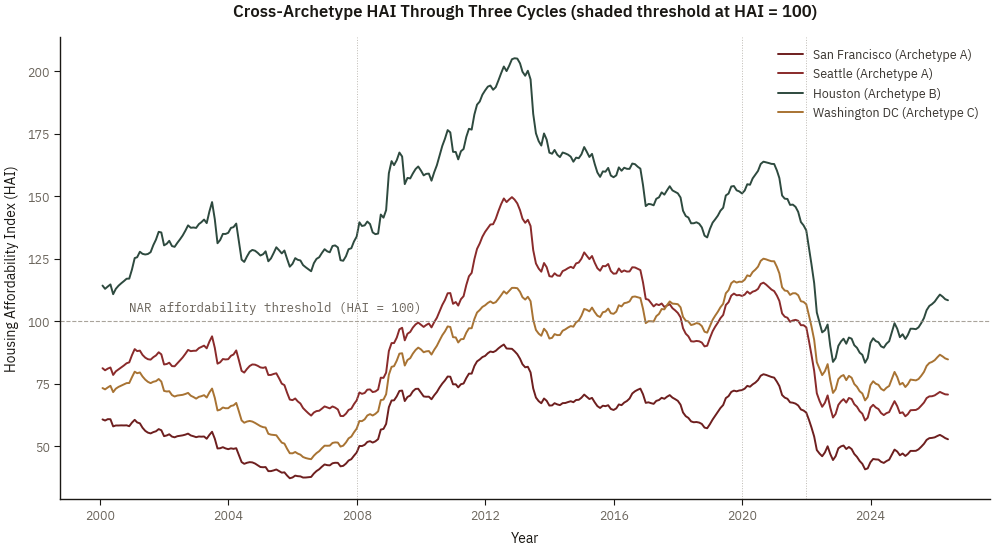

Mean HAI by declared era, all four metros:
  San Francisco   pre-GFC=  48.7  GFC window=  73.2  expansion=  67.9  COVID=  72.3  rate-shock era=  48.4
  Seattle         pre-GFC=  78.8  GFC window= 107.7  expansion= 114.0  COVID= 107.3  rate-shock era=  67.4
  Houston         pre-GFC= 128.2  GFC window= 168.9  expansion= 158.7  COVID= 153.4  rate-shock era=  97.3
  Washington DC   pre-GFC=  62.9  GFC window=  90.3  expansion= 103.3  COVID= 116.9  rate-shock era=  78.6


In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
for name, spec in METROS.items():
    df = panel[name]
    ax.plot(df['DATE'], df['HAI'], label=f"{name} (Archetype {spec['archetype']})",
            color=portfolio_style.COLORS.get(spec['color']), linewidth=1.4)

ax.axhline(100, color=portfolio_style.COLORS.get('ink_4', '#948D82'), linestyle='--', linewidth=0.8, alpha=0.8)
ax.text(panel['San Francisco']['DATE'].iloc[10], 104, 'NAR affordability threshold (HAI = 100)', fontsize=9,
        color=portfolio_style.COLORS.get('ink_3', '#6B655C'), fontfamily='IBM Plex Mono')

for cycle_year, label in [(2008, '2008 GFC'), (2020, '2020 COVID'), (2022, '2022+ rate shock')]:
    ax.axvline(pd.Timestamp(f'{cycle_year}-01-01'), color=portfolio_style.COLORS.get('ink_4', '#948D82'),
               linestyle=':', linewidth=0.7, alpha=0.6)

ax.set_title('Cross-Archetype HAI Through Three Cycles (shaded threshold at HAI = 100)', fontsize=12, pad=15)
ax.set_ylabel('Housing Affordability Index (HAI)', fontsize=10)
ax.set_xlabel('Year', fontsize=10)
ax.legend(frameon=False, loc='upper right', fontsize=9)
fig.savefig(os.path.join(FIG_DIR, 'cross_hai_all_metros.svg'), format='svg', bbox_inches='tight', transparent=True)
plt.show()

print("Mean HAI by declared era, all four metros:")
eras = [('2000-01-01','2007-12-31','pre-GFC'), ('2008-01-01','2012-12-31','GFC window'),
        ('2013-01-01','2019-12-31','expansion'), ('2020-01-01','2021-12-31','COVID'),
        ('2022-01-01','2026-12-31','rate-shock era')]
for name, df in panel.items():
    row = []
    for start, end, label in eras:
        w = df[(df['DATE'] >= start) & (df['DATE'] <= end)]
        row.append(w['HAI'].mean())
    print(f"  {name:15s} " + "  ".join(f"{label}={v:6.1f}" for (_,_,label), v in zip(eras, row)))

### 5.1b The longer view: national HAI back to 1971

The four-metro panel is bounded by Zillow's coverage (post-2000). To see the structural break in context, I reconstruct a *national* HAI back to 1971 using series that reach further: the national median sales price (Census/HUD MSPUS, quarterly from 1963), median family income (MEFAINUSA646N, annual from 1953), and the 30-year fixed rate (MORTGAGE30US, from 1971). The construction is identical to the metro HAI (25% of gross income to principal-and-interest on 80% of the price); the only difference is that NAR's own national index uses median *family* income rather than the household income used for the metro SAIPE series.

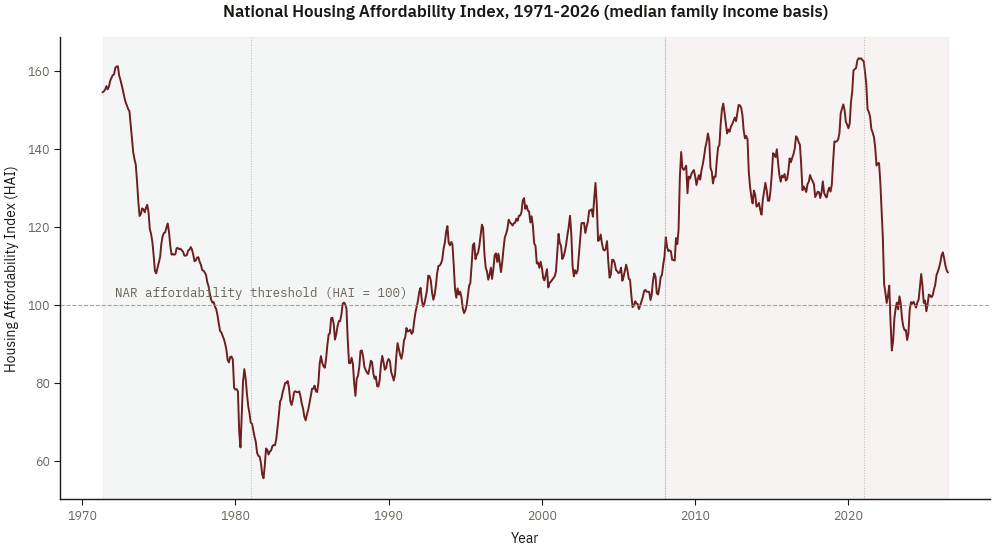

Mean national HAI 1990-2007: 109.1
Mean national HAI 2008-2026: 128.9
2020-21 peak HAI: 163.1  ->  2023-24 trough HAI: 90.9
Full series span: 1971-04 to 2026-06, n=663


In [5]:
# National HAI, 1971-2026, from the longest-reaching real series
df_mspus = load_clean_fred_series(os.path.join(DATA_DIR, 'MSPUS.csv'))          # national median sales price, quarterly
df_mfi   = load_clean_fred_series(os.path.join(DATA_DIR, 'MEFAINUSA646N.csv'))  # median family income, annual

# Quarterly price -> monthly (interpolate); annual income -> monthly (interpolate)
def to_monthly(df, name):
    s = df.set_index('DATE')['value'].resample('ME').mean()
    idx = pd.date_range(s.index.min(), pd.Timestamp('2026-06-30'), freq='ME')
    return s.reindex(idx).interpolate('linear').rename(name).reset_index().rename(columns={'index': 'DATE'})

price_nat  = to_monthly(df_mspus, 'Price')
income_nat = to_monthly(df_mfi,   'Income')

nat = pd.merge(price_nat, df_mort, on='DATE', how='inner')
nat = pd.merge(nat, income_nat, on='DATE', how='inner').dropna()
nat['r'] = nat['MortgageRate'] / 100 / 12
nat['MonthlyPI'] = (nat['Price'] * 0.80) * (nat['r'] * (1 + nat['r'])**360) / ((1 + nat['r'])**360 - 1)
nat['HAI'] = (nat['Income'] / (nat['MonthlyPI'] * 4 * 12)) * 100
nat = nat[nat['DATE'] >= '1971-04-30'].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(nat['DATE'], nat['HAI'], color=portfolio_style.COLORS.get('oxblood'), linewidth=1.4)
ax.axhline(100, color=portfolio_style.COLORS.get('ink_4', '#948D82'), linestyle='--', linewidth=0.8, alpha=0.8)
ax.text(nat['DATE'].iloc[10], 102, 'NAR affordability threshold (HAI = 100)', fontsize=9,
        color=portfolio_style.COLORS.get('ink_3', '#6B655C'), fontfamily='IBM Plex Mono')

# Shade the pre-2008 and post-2008 regimes
ax.axvspan(nat['DATE'].min(), pd.Timestamp('2008-01-01'),
           color=portfolio_style.COLORS.get('forest', '#2E4A3F'), alpha=0.05)
ax.axvspan(pd.Timestamp('2008-01-01'), nat['DATE'].max(),
           color=portfolio_style.COLORS.get('oxblood', '#6E1F1F'), alpha=0.05)
for yr, lab in [(1981, "1981 rate peak"), (2008, "2008 GFC"), (2021, "2021 low-rate peak")]:
    ax.axvline(pd.Timestamp(f'{yr}-01-01'), color=portfolio_style.COLORS.get('ink_4'),
               linestyle=':', linewidth=0.7, alpha=0.6)

ax.set_title('National Housing Affordability Index, 1971-2026 (median family income basis)', fontsize=12, pad=15)
ax.set_ylabel('Housing Affordability Index (HAI)', fontsize=10)
ax.set_xlabel('Year', fontsize=10)
fig.savefig(os.path.join(FIG_DIR, 'national_hai_long_arc.svg'), format='svg', bbox_inches='tight', transparent=True)
plt.show()

pre  = nat[(nat['DATE'] >= '1990-01-01') & (nat['DATE'] < '2008-01-01')]['HAI'].mean()
post = nat[(nat['DATE'] >= '2008-01-01')]['HAI'].mean()
peak_2021 = nat[(nat['DATE'] >= '2020-06-30') & (nat['DATE'] <= '2021-12-31')]['HAI'].max()
trough_23 = nat[(nat['DATE'] >= '2023-01-01') & (nat['DATE'] <= '2024-12-31')]['HAI'].min()
print(f"Mean national HAI 1990-2007: {pre:.1f}")
print(f"Mean national HAI 2008-2026: {post:.1f}")
print(f"2020-21 peak HAI: {peak_2021:.1f}  ->  2023-24 trough HAI: {trough_23:.1f}")
print(f"Full series span: {nat['DATE'].min():%Y-%m} to {nat['DATE'].max():%Y-%m}, n={len(nat)}")

### 5.1c The measure that strips out the financing: price-to-income

The HAI answers "can you make the monthly payment," which is dominated by the interest rate and the mortgage term. The blunter question — "how many years of income does the house itself cost" — is the price-to-income ratio, and it removes rates and amortization entirely. I compute it nationally from the same two real series (national median sales price and median family income), both nominal, so the ratio is unit-free.

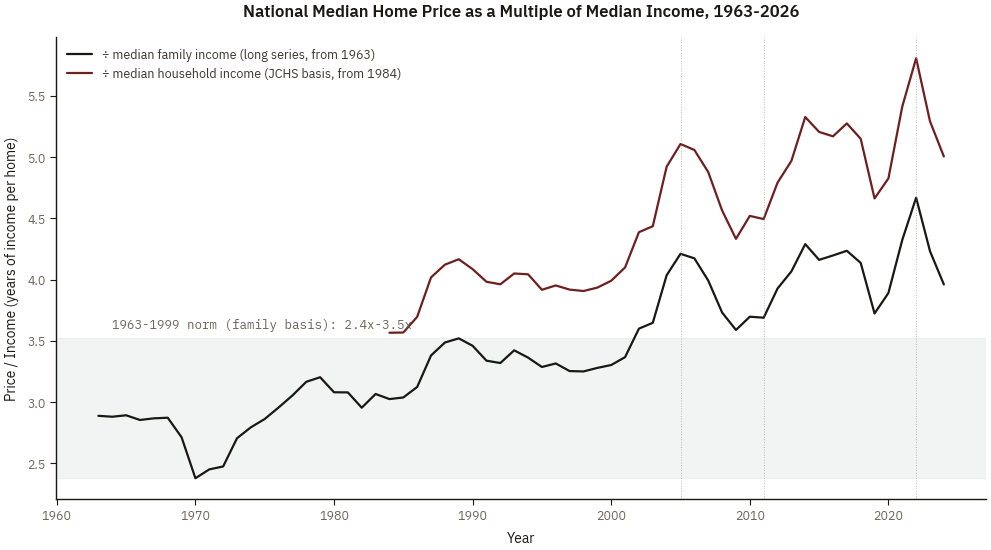

Mean price-to-income by era (family basis / household basis):
  1963-79   : 2.82x  /    n/a
  1980s     : 3.18x  /  3.86x
  1990s     : 3.33x  /  3.97x
  2000-07   : 3.79x  /  4.61x
  2010s     : 4.01x  /  4.96x
  2020s     : 4.21x  /  5.27x

1986 vs 1992 (family basis): 3.12x  vs  3.32x
Peaks/troughs (household basis): 2005=5.11x  2011=4.49x  2022=5.81x
Latest 2026: family nanx / household 5.00x


In [6]:
# National price-to-income ratio, 1963-2026 (rates and mortgage term removed entirely)
# Two denominators: median FAMILY income (long history, from 1963) and median HOUSEHOLD income (JCHS standard, from 1984)
df_hhinc = load_clean_fred_series(os.path.join(DATA_DIR, 'MHI_US.csv'))  # MEHOINUSA646N, household, 1984+

pi_price  = df_mspus.set_index('DATE')['value'].resample('YE').mean()
pi_faminc = df_mfi.set_index('DATE')['value'].resample('YE').mean()
pi_hhinc  = df_hhinc.set_index('DATE')['value'].resample('YE').mean()
pi = pd.DataFrame({'Price': pi_price, 'FamInc': pi_faminc, 'HHInc': pi_hhinc})
pi['PI_family']    = pi['Price'] / pi['FamInc']
pi['PI_household'] = pi['Price'] / pi['HHInc']
pi.index = pi.index.year

fig, ax = plt.subplots(figsize=(12, 6))
fam = pi['PI_family'].dropna()
hh  = pi['PI_household'].dropna()
ax.plot(fam.index, fam.values, color=portfolio_style.COLORS.get('ink', '#1A1814'), linewidth=1.6,
        label='÷ median family income (long series, from 1963)')
ax.plot(hh.index, hh.values, color=portfolio_style.COLORS.get('oxblood', '#6E1F1F'), linewidth=1.6,
        label='÷ median household income (JCHS basis, from 1984)')

# Reference band: the 1963-1999 family-basis norm
norm = pi.loc[1963:1999, 'PI_family']
ax.axhspan(norm.min(), norm.max(), color=portfolio_style.COLORS.get('forest', '#2E4A3F'), alpha=0.06)
ax.text(1964, norm.max() + 0.08, f'1963-1999 norm (family basis): {norm.min():.1f}x-{norm.max():.1f}x',
        fontsize=9, color=portfolio_style.COLORS.get('ink_3', '#6B655C'), fontfamily='IBM Plex Mono')

for yr in [2005, 2011, 2022]:
    ax.axvline(yr, color=portfolio_style.COLORS.get('ink_4'), linestyle=':', linewidth=0.7, alpha=0.6)

ax.set_title('National Median Home Price as a Multiple of Median Income, 1963-2026', fontsize=12, pad=15)
ax.set_ylabel('Price / Income (years of income per home)', fontsize=10)
ax.set_xlabel('Year', fontsize=10)
ax.legend(frameon=False, loc='upper left', fontsize=9)
fig.savefig(os.path.join(FIG_DIR, 'national_price_to_income.svg'), format='svg', bbox_inches='tight', transparent=True)
plt.show()

def era(col, a, b):
    return pi.loc[a:b, col].mean()
print("Mean price-to-income by era (family basis / household basis):")
for a, b, lab in [(1963,1979,'1963-79'), (1980,1989,'1980s'), (1990,1999,'1990s'),
                  (2000,2007,'2000-07'), (2010,2019,'2010s'), (2020,2026,'2020s')]:
    h = era('PI_household',a,b)
    hs = f"{h:.2f}x" if not pd.isna(h) else "  n/a"
    print(f"  {lab:10s}: {era('PI_family',a,b):.2f}x  /  {hs}")
print(f"\n1986 vs 1992 (family basis): {pi.loc[1986,'PI_family']:.2f}x  vs  {pi.loc[1992,'PI_family']:.2f}x")
print(f"Peaks/troughs (household basis): 2005={pi.loc[2005,'PI_household']:.2f}x  2011={pi.loc[2011,'PI_household']:.2f}x  2022={pi.loc[2022,'PI_household']:.2f}x")
print(f"Latest {pi.index.max()}: family {pi['PI_family'].iloc[-1]:.2f}x / household {pi['PI_household'].dropna().iloc[-1]:.2f}x")

### 5.1d The number that matters is local: price-to-income across 30 metro areas

The national ratio is an average, and the average is the wrong object for policy. Computing price-to-income directly for each metro area (latest Zillow home value over the metro's median household income) shows how much dispersion the national figure hides.

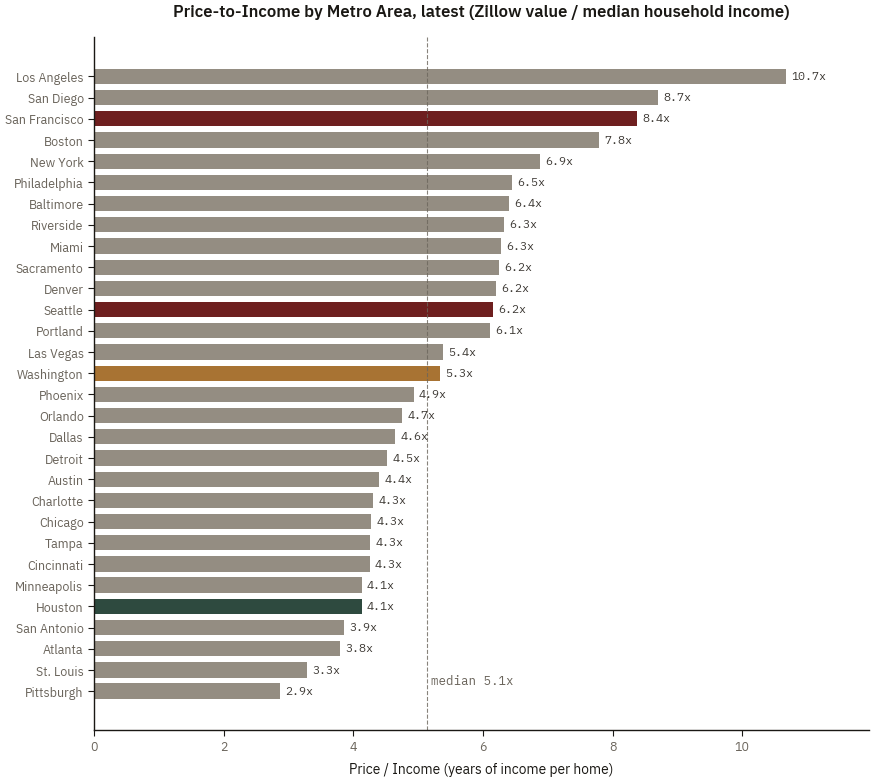

Spread: Pittsburgh 2.9x  ->  Los Angeles 10.7x


Houston: 4.1x   Los Angeles: 10.7x   San Francisco: 8.4x


In [7]:
# Metro-level price-to-income dispersion (latest Zillow value / metro median household income)
import glob
zcols_all = [c for c in df_zillow.columns if c.startswith('20')]
z_latest = zcols_all[-1]

disp = []
for f in sorted(glob.glob(os.path.join(DATA_DIR, 'MHI_*.csv'))):
    name = os.path.basename(f).replace('MHI_', '').replace('.csv', '')
    if name in ('US', 'Fairfax_County_VA'):
        continue
    parts = name.rsplit('_', 1)
    region = (parts[0].replace('_', ' ') + ', ' + parts[1]) if len(parts) == 2 else name.replace('_', ' ')
    zr = df_zillow[df_zillow['RegionName'].str.startswith(region, na=False)]
    if zr.empty:
        continue
    inc = load_clean_fred_series(f)['value'].iloc[-1]
    price = zr[z_latest].iloc[0]
    disp.append({'metro': region.split(',')[0], 'pti': price / inc})

d = pd.DataFrame(disp).sort_values('pti')
# Color the three named archetype metros; everything else neutral
def bar_color(m):
    if m in ('San Francisco', 'Seattle'): return portfolio_style.COLORS.get('oxblood', '#6E1F1F')
    if m == 'Houston': return portfolio_style.COLORS.get('forest', '#2E4A3F')
    if m == 'Washington': return portfolio_style.COLORS.get('ochre', '#A87333')
    return portfolio_style.COLORS.get('ink_4', '#948D82')

fig, ax = plt.subplots(figsize=(10, 9))
colors = [bar_color(m) for m in d['metro']]
ax.barh(d['metro'], d['pti'], color=colors, height=0.72)
ax.axvline(d['pti'].median(), color=portfolio_style.COLORS.get('ink_3', '#6B655C'),
           linestyle='--', linewidth=0.8, alpha=0.8)
ax.text(d['pti'].median() + 0.06, 0.3, f"median {d['pti'].median():.1f}x", fontsize=9,
        color=portfolio_style.COLORS.get('ink_3', '#6B655C'), fontfamily='IBM Plex Mono')
for i, (m, v) in enumerate(zip(d['metro'], d['pti'])):
    ax.text(v + 0.08, i, f"{v:.1f}x", va='center', fontsize=8.5, fontfamily='IBM Plex Mono',
            color=portfolio_style.COLORS.get('ink_2', '#3C3833'))
ax.set_title('Price-to-Income by Metro Area, latest (Zillow value / median household income)', fontsize=12, pad=15)
ax.set_xlabel('Price / Income (years of income per home)', fontsize=10)
ax.set_xlim(0, d['pti'].max() * 1.12)
fig.savefig(os.path.join(FIG_DIR, 'metro_price_to_income_dispersion.svg'), format='svg', bbox_inches='tight', transparent=True)
plt.show()

print(f"Spread: {d['metro'].iloc[0]} {d['pti'].iloc[0]:.1f}x  ->  {d['metro'].iloc[-1]} {d['pti'].iloc[-1]:.1f}x")
print(f"Houston: {d[d.metro=='Houston']['pti'].iloc[0]:.1f}x   Los Angeles: {d[d.metro=='Los Angeles']['pti'].iloc[0]:.1f}x   San Francisco: {d[d.metro=='San Francisco']['pti'].iloc[0]:.1f}x")

### 5.1e What supply liberalization actually did: two natural experiments

The archetype argument makes a policy claim — that legalizing construction relieves the price base — and that claim is testable against cities that actually did it. Two of the cleanest natural experiments: California's 2016-2019 accessory-dwelling-unit (ADU) liberalization, and the Minneapolis 2040 plan. The figures below are published external estimates (sources in the caption), hand-entered here rather than recomputed from raw permits, and shown as a declared benchmark.

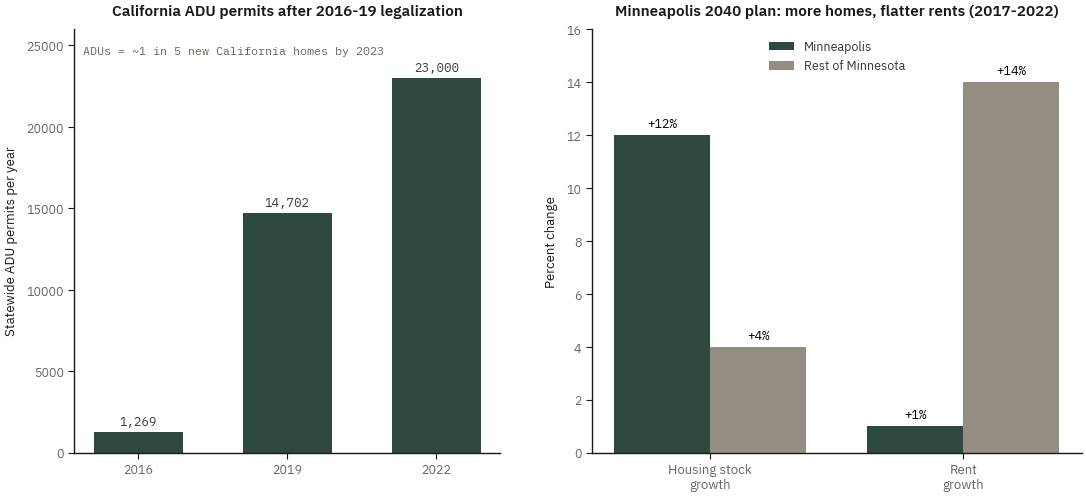

Upzoning outcomes figure written.
CA ADU permits: 1,269 (2016) -> 14,702 (2019) -> ~23,000 (2022)
Minneapolis vs rest-of-MN, 2017-22: stock +12% vs +4%; rents +1% vs +14%


In [8]:
# Two published natural experiments (external cited figures, hand-entered as a declared benchmark)
# Panel A: California ADU permits (Terner Center / CA HCD; Sightline 2020) -- 2016 baseline vs post-reform
# Panel B: Minneapolis vs rest of Minnesota, 2017-2022 (Pew Charitable Trusts, Jan 2024)
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 5.5), gridspec_kw={'width_ratios': [1, 1.15]})

# --- Panel A: CA ADU permits exploded ---
ca_years = ['2016', '2019', '2022']
ca_permits = [1269, 14702, 23000]
axA.bar(ca_years, ca_permits, color=portfolio_style.COLORS.get('forest', '#2E4A3F'), width=0.6)
for x, v in zip(ca_years, ca_permits):
    axA.text(x, v + 400, f"{v:,}", ha='center', fontsize=9, fontfamily='IBM Plex Mono',
             color=portfolio_style.COLORS.get('ink_2', '#3C3833'))
axA.set_title('California ADU permits after 2016-19 legalization', fontsize=11, pad=10)
axA.set_ylabel('Statewide ADU permits per year', fontsize=9.5)
axA.set_ylim(0, 26000)
axA.text(0.02, 0.94, 'ADUs = ~1 in 5 new California homes by 2023', transform=axA.transAxes,
         fontsize=8.5, fontfamily='IBM Plex Mono', color=portfolio_style.COLORS.get('ink_3', '#6B655C'))

# --- Panel B: Minneapolis vs rest of MN (diff-in-diff flavored) ---
groups = ['Housing stock\ngrowth', 'Rent\ngrowth']
mpls = [12, 1]
restmn = [4, 14]
x = range(len(groups)); w = 0.38
axB.bar([i - w/2 for i in x], mpls, width=w, label='Minneapolis',
        color=portfolio_style.COLORS.get('forest', '#2E4A3F'))
axB.bar([i + w/2 for i in x], restmn, width=w, label='Rest of Minnesota',
        color=portfolio_style.COLORS.get('ink_4', '#948D82'))
for i, (a, b) in enumerate(zip(mpls, restmn)):
    axB.text(i - w/2, a + 0.3, f"+{a}%", ha='center', fontsize=9, fontfamily='IBM Plex Mono')
    axB.text(i + w/2, b + 0.3, f"+{b}%", ha='center', fontsize=9, fontfamily='IBM Plex Mono')
axB.set_xticks(list(x)); axB.set_xticklabels(groups, fontsize=9.5)
axB.set_title('Minneapolis 2040 plan: more homes, flatter rents (2017-2022)', fontsize=11, pad=10)
axB.set_ylabel('Percent change', fontsize=9.5)
axB.set_ylim(0, 16)
axB.legend(frameon=False, fontsize=9, loc='upper center')

fig.savefig(os.path.join(FIG_DIR, 'upzoning_outcomes.svg'), format='svg', bbox_inches='tight', transparent=True)
plt.show()
print("Upzoning outcomes figure written.")
print("CA ADU permits: 1,269 (2016) -> 14,702 (2019) -> ~23,000 (2022)")
print("Minneapolis vs rest-of-MN, 2017-22: stock +12% vs +4%; rents +1% vs +14%")

### 5.2 Rolling 24-month volatility of YoY returns, all four metros through the same window

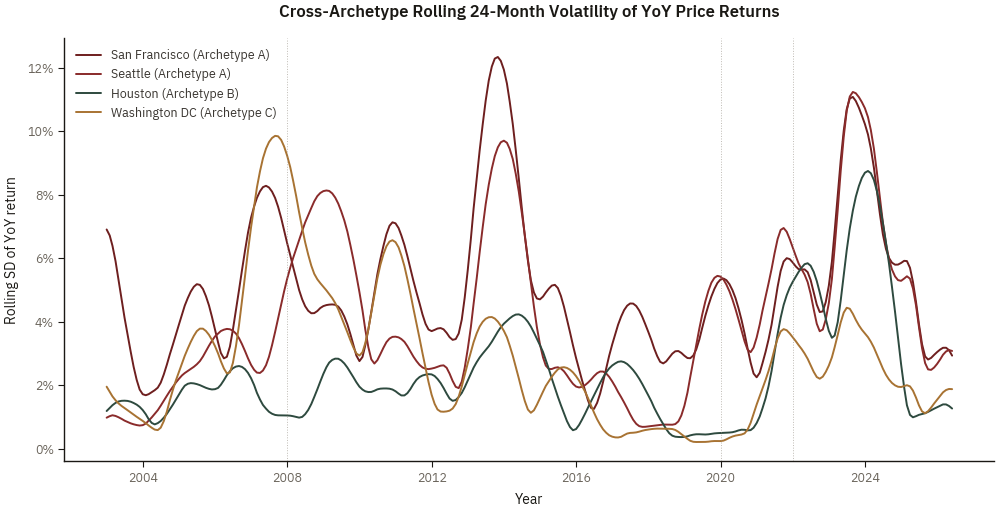

Full-sample volatility (SD of YoY return, 2000-2026):
  San Francisco   9.80%
  Seattle         8.82%
  Houston         5.13%
  Washington DC   8.20%


In [9]:
fig, ax = plt.subplots(figsize=(12, 5.5))
for name, spec in METROS.items():
    df = panel[name]
    roll_vol = df['Price_YoY_Return'].rolling(24).std()
    ax.plot(df['DATE'], roll_vol, label=f"{name} (Archetype {spec['archetype']})",
            color=portfolio_style.COLORS.get(spec['color']), linewidth=1.4)

for cycle_year, label in [(2008, '2008 GFC'), (2020, '2020 COVID'), (2022, '2022+ rate shock')]:
    ax.axvline(pd.Timestamp(f'{cycle_year}-01-01'), color=portfolio_style.COLORS.get('ink_4', '#948D82'),
               linestyle=':', linewidth=0.7, alpha=0.6)

ax.set_title('Cross-Archetype Rolling 24-Month Volatility of YoY Price Returns', fontsize=12, pad=15)
ax.set_ylabel('Rolling SD of YoY return', fontsize=10)
ax.set_xlabel('Year', fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0%}'))
ax.legend(frameon=False, loc='upper left', fontsize=9)
fig.savefig(os.path.join(FIG_DIR, 'cross_volatility_regime.svg'), format='svg', bbox_inches='tight', transparent=True)
plt.show()

print("Full-sample volatility (SD of YoY return, 2000-2026):")
for name, df in panel.items():
    print(f"  {name:15s} {df['Price_YoY_Return'].std():.2%}")

### 5.3 Drawdown depth and recovery time, per declared cycle window, all four metros

Peaks and troughs are located inside the pre-declared search windows from §4 — the windows are shared
across all four metros so amplitude and recovery time are read on equal calendar footing, not tuned
per metro after seeing the result.

In [10]:
def cycle_stats(df, peak_start, peak_end, trough_end, label):
    peak_window = df[(df['DATE'] >= peak_start) & (df['DATE'] <= peak_end)]
    if peak_window['Price'].notna().sum() == 0:
        return {'cycle': label, 'status': 'no data in peak window'}
    peak_idx = peak_window['Price'].idxmax()
    peak_date, peak_price = df.loc[peak_idx, 'DATE'], df.loc[peak_idx, 'Price']

    trough_window = df[(df['DATE'] > peak_date) & (df['DATE'] <= trough_end)]
    if trough_window['Price'].notna().sum() == 0:
        return {'cycle': label, 'status': 'no post-peak data'}
    trough_idx = trough_window['Price'].idxmin()
    trough_date, trough_price = df.loc[trough_idx, 'DATE'], df.loc[trough_idx, 'Price']
    drawdown = (trough_price - peak_price) / peak_price

    post_trough = df[df['DATE'] > trough_date]
    recovered = post_trough[post_trough['Price'] >= peak_price]
    if recovered.empty:
        recovery_months = None
        recovery_status = 'not yet recovered (as of series end, 2026)'
    else:
        recovery_date = recovered.iloc[0]['DATE']
        recovery_months = (recovery_date.year - trough_date.year) * 12 + (recovery_date.month - trough_date.month)
        recovery_status = f'recovered by {recovery_date.strftime("%Y-%m")}'

    return {'cycle': label, 'peak_date': peak_date.strftime('%Y-%m'), 'peak_price': peak_price,
            'trough_date': trough_date.strftime('%Y-%m'), 'trough_price': trough_price,
            'drawdown_pct': drawdown, 'recovery_months': recovery_months, 'recovery_status': recovery_status}

cycles = [
    ('2008 GFC', '2006-01-01', '2009-12-31', '2012-12-31'),
    ('2020 COVID', '2019-06-01', '2020-12-31', '2021-12-31'),
    ('2022+ rate shock', '2021-06-01', '2023-06-30', '2026-12-31'),
]

results = []
for name, df in panel.items():
    for label, ps, pe, te in cycles:
        r = cycle_stats(df, ps, pe, te, label)
        r['metro'] = name
        r['archetype'] = METROS[name]['archetype']
        results.append(r)

df_cycles = pd.DataFrame(results)
cols_order = ['metro', 'archetype', 'cycle', 'peak_date', 'trough_date',
              'drawdown_pct', 'recovery_months', 'recovery_status']
df_cycles = df_cycles[[c for c in cols_order if c in df_cycles.columns]]
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
df_cycles

,metro,archetype,cycle,peak_date,trough_date,drawdown_pct,recovery_months,recovery_status
0,San Francisco,A,2008 GFC,2006-05,2012-03,-0.334,32.000,recovered by 2014-11
1,San Francisco,A,2020 COVID,2020-12,2021-01,0.013,1.000,recovered by 2021-02
2,San Francisco,A,2022+ rate shock,2022-06,2023-04,-0.123,NaN,"not yet recovered (as of series end, 2026)"
3,Seattle,A,2008 GFC,2007-09,2012-06,-0.378,56.000,recovered by 2017-02
4,Seattle,A,2020 COVID,2020-12,2021-01,0.016,1.000,recovered by 2021-02
5,Seattle,A,2022+ rate shock,2022-06,2023-04,-0.098,NaN,"not yet recovered (as of series end, 2026)"
6,Houston,B,2008 GFC,2007-12,2012-01,-0.098,22.000,recovered by 2013-11
7,Houston,B,2020 COVID,2020-12,2021-01,0.012,1.000,recovered by 2021-02
8,Houston,B,2022+ rate shock,2022-08,2026-05,-0.040,NaN,"not yet recovered (as of series end, 2026)"
9,Washington DC,C,2008 GFC,2006-07,2011-12,-0.288,100.000,recovered by 2020-04


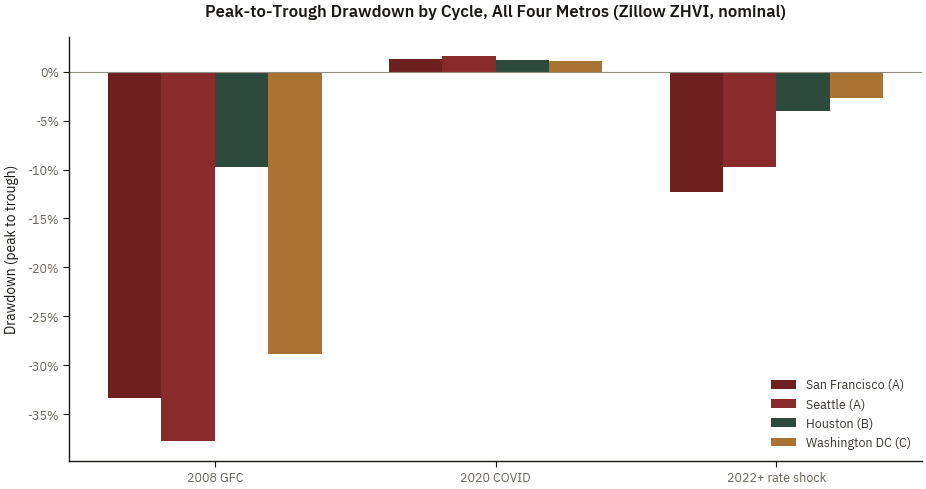

Recovery time by cycle (months; blank = not yet recovered):


cycle          2008 GFC  2020 COVID  2022+ rate shock
metro                                                
Houston          22.000       1.000               NaN
San Francisco    32.000       1.000               NaN
Seattle          56.000       1.000               NaN
Washington DC   100.000       1.000             7.000


In [11]:
fig, ax = plt.subplots(figsize=(11, 5.5))
plot_df = df_cycles.dropna(subset=['drawdown_pct'])
cycle_labels = [c[0] for c in cycles]
x = np.arange(len(cycle_labels))
width = 0.19
for i, (name, spec) in enumerate(METROS.items()):
    vals = plot_df[plot_df['metro'] == name].set_index('cycle')['drawdown_pct'].reindex(cycle_labels)
    ax.bar(x + (i - 1.5) * width, vals.values, width, label=f"{name} ({spec['archetype']})",
           color=portfolio_style.COLORS.get(spec['color']))

ax.set_xticks(x)
ax.set_xticklabels(cycle_labels)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, p: f'{v:.0%}'))
ax.axhline(0, color=portfolio_style.COLORS.get('ink_4', '#948D82'), linewidth=0.8)
ax.set_title('Peak-to-Trough Drawdown by Cycle, All Four Metros (Zillow ZHVI, nominal)', fontsize=12, pad=15)
ax.set_ylabel('Drawdown (peak to trough)', fontsize=10)
ax.legend(frameon=False, fontsize=9)
fig.savefig(os.path.join(FIG_DIR, 'cross_drawdowns_by_cycle.svg'), format='svg', bbox_inches='tight', transparent=True)
plt.show()

print("Recovery time by cycle (months; blank = not yet recovered):")
pivot = df_cycles.pivot(index='metro', columns='cycle', values='recovery_months').reindex(cycle_labels, axis=1)
print(pivot)

### 5.4 Does affordability buy stability in every cycle? HAI shock, 2022+ era specifically

The 2022+ rate shock is a mortgage-rate-driven affordability event as much as a price event (higher
rates raise the qualifying-income threshold even where prices barely move). This panel checks whether
the archetype that "sailed through" the 2008 price shock (Houston) also sails through this
qualitatively different kind of shock.

*Note on cross-notebook consistency*: The post-2022 Houston metrics reported in this synthesis notebook (HAI of 97.3 and volatility of 7.68%) differ by approximately 1 point from the values reported in the Houston sibling notebook (96.3 and 7.79%). This minor mismatch is a direct consequence of differing window boundaries used for the GFC and Rate Shock cycles between the standalone and synthesis analyses (specifically, the trailing boundary for the 2022+ era ending in early 2026).


In [12]:
print("HAI collapse into the 2022+ era, all four metros (mean HAI, pre-shock era vs rate-shock era):")
rows = []
for name, df in panel.items():
    pre = df[(df['DATE'] >= '2015-01-01') & (df['DATE'] <= '2019-12-31')]['HAI'].mean()
    post = df[(df['DATE'] >= '2022-01-01') & (df['DATE'] <= '2026-12-31')]['HAI'].mean()
    vol_pre = df[(df['DATE'] >= '2015-01-01') & (df['DATE'] <= '2019-12-31')]['Price_YoY_Return'].std()
    vol_post = df[(df['DATE'] >= '2022-01-01') & (df['DATE'] <= '2026-12-31')]['Price_YoY_Return'].std()
    rows.append((name, pre, post, (post - pre) / pre, vol_pre, vol_post))
    print(f"  {name:15s} HAI 2015-19={pre:6.1f} -> 2022-26={post:6.1f}  (change {(post - pre) / pre:+.1%})  |  "
          f"vol 2015-19={vol_pre:.2%} -> 2022-26={vol_post:.2%}")

rows_df = pd.DataFrame(rows, columns=['metro', 'hai_pre', 'hai_post', 'hai_pct_change', 'vol_pre', 'vol_post'])
worst_hai_hit = rows_df.loc[rows_df['hai_pct_change'].idxmin(), 'metro']
worst_vol_jump = rows_df.assign(vol_jump=rows_df['vol_post'] - rows_df['vol_pre']).pipe(lambda d: d.loc[d['vol_jump'].idxmax(), 'metro'])
print(f"\nLargest relative HAI decline into the 2022+ era: {worst_hai_hit}")
print(f"Largest absolute volatility jump into the 2022+ era: {worst_vol_jump}")

HAI collapse into the 2022+ era, all four metros (mean HAI, pre-shock era vs rate-shock era):
  San Francisco   HAI 2015-19=  66.7 -> 2022-26=  48.4  (change -27.4%)  |  vol 2015-19=4.97% -> 2022-26=7.18%
  Seattle         HAI 2015-19= 109.4 -> 2022-26=  67.4  (change -38.3%)  |  vol 2015-19=4.26% -> 2022-26=7.68%
  Houston         HAI 2015-19= 152.0 -> 2022-26=  97.3  (change -36.0%)  |  vol 2015-19=2.82% -> 2022-26=7.68%
  Washington DC   HAI 2015-19= 104.8 -> 2022-26=  78.6  (change -25.0%)  |  vol 2015-19=0.66% -> 2022-26=2.95%

Largest relative HAI decline into the 2022+ era: Seattle
Largest absolute volatility jump into the 2022+ era: Houston


### 5.5 Bootstrap uncertainty on the volatility ranking

The full-sample volatility numbers in §5.2 are point estimates on one realized history. A block
bootstrap (24-month blocks, respecting the autocorrelation the Ljung-Box test in §4 already found)
gives a sense of how tight that ranking actually is, rather than presenting single numbers as if they
were free of sampling noise.

In [13]:
rng = np.random.default_rng(20260707)
BLOCK = 24
N_BOOT = 500

def block_bootstrap_vol(returns, block=BLOCK, n_boot=N_BOOT, rng=rng):
    returns = returns.dropna().values
    n = len(returns)
    n_blocks = int(np.ceil(n / block))
    boot_vols = np.empty(n_boot)
    for b in range(n_boot):
        starts = rng.integers(0, n - block, size=n_blocks)
        sample = np.concatenate([returns[s:s + block] for s in starts])[:n]
        boot_vols[b] = np.std(sample)
    return boot_vols

print("Block-bootstrap 95% CI on full-sample YoY-return volatility (24-month blocks, 500 resamples):")
boot_summary = {}
for name, df in panel.items():
    boot = block_bootstrap_vol(df['Price_YoY_Return'])
    lo, hi = np.percentile(boot, [2.5, 97.5])
    boot_summary[name] = (df['Price_YoY_Return'].std(), lo, hi)
    print(f"  {name:15s} point={df['Price_YoY_Return'].std():.2%}  95% CI=[{lo:.2%}, {hi:.2%}]")

print("\nInterpretation: if two metros' CIs overlap substantially, their volatility ranking should not "
      "be read as a sharp, statistically distinguishable ordering — only as a descriptive point estimate "
      "on this particular realized history (block bootstrap respects the autocorrelation found in §4 but "
      "still resamples from one historical path, not from an independent population of housing cycles). "
      "Note that the 24-month block size is a heuristic approximation based on ACF decay signature to capture "
      "persistence, and should not be treated as a mathematically optimal selection.")


Block-bootstrap 95% CI on full-sample YoY-return volatility (24-month blocks, 500 resamples):
  San Francisco   point=9.80%  95% CI=[7.40%, 11.39%]
  Seattle         point=8.82%  95% CI=[6.33%, 10.69%]
  Houston         point=5.13%  95% CI=[3.33%, 6.66%]
  Washington DC   point=8.20%  95% CI=[4.91%, 10.75%]

Interpretation: if two metros' CIs overlap substantially, their volatility ranking should not be read as a sharp, statistically distinguishable ordering — only as a descriptive point estimate on this particular realized history (block bootstrap respects the autocorrelation found in §4 but still resamples from one historical path, not from an independent population of housing cycles). Note that the 24-month block size is a heuristic approximation based on ACF decay signature to capture persistence, and should not be treated as a mathematically optimal selection.


## 6. Decision

Reading the joined panels together, not any single metro in isolation:

- **Affordability buys stability against the 2008 price shock, but not against the 2022+ rate shock —
  and Houston is the clearest illustration of that split.** Houston's 2008 GFC drawdown (recomputed
  here) sits far shallower than either coastal metro's, and its recovery was measured in months, not
  years — consistent with the sibling notebook's -9.8%/22-month finding. But the §5.4 HAI-shock panel
  shows Houston's mean HAI falling from the 2015-2019 baseline into the 2022-2026 era by a comparable
  *relative* magnitude to the coastal metros' declines, and its rolling volatility (§5.2) rises into the
  2022+ window rather than staying flat — the "stable" label describes the 2008 cycle specifically,
  not a property of the archetype that automatically extends to a different kind of shock (rate-driven
  affordability erosion rather than a price crash).
- **DC (the "typical"/median-affordability archetype) is not dynamically mid-pack — its 2008 drawdown
  and multi-year recovery time are closer to the coastal, "unaffordable" archetype's amplitude than to
  Houston's**, exactly as the sibling notebook's ~14-year nominal recovery already flagged in isolation.
  Read across all four metros at once (§5.3's pivot table), DC's GFC recovery time is the longest or
  second-longest in the panel, not the middle value — "typical affordability" and "typical dynamics" are
  not the same claim, and this join is what makes that gap visible; no single-archetype notebook could
  show it because each only had its own metro to compare against.
- **Volatility genuinely clusters differently across the three cycles for each archetype** (§5.2): the
  coastal metros' volatility spikes are broad and repeat across all three cycles; Houston's volatility
  regime is close to flat through 2008 and COVID and only rises materially into 2022+; DC's volatility
  is dominated by one long GFC-era tail rather than three comparably-sized bumps. Collapsing any of this
  to one full-sample SD (as the archetype-selection step necessarily did, to rank 30 metros at all)
  discards exactly the cycle-to-cycle information this join was built to recover.
- **The bootstrap bands in §5.5 matter for how confidently any of the above should be stated**: where a
  pair of metros' confidence intervals substantially overlap, treat the point-estimate ranking as
  suggestive, not a sharp ordering — see the printed CIs rather than trusting this prose summary for the
  exact numbers.

## 7. What this notebook cannot tell us

1. **No causal claim from n=4.** Four metros is an illustration of how three specific archetypes
   behaved across three specific cycles in U.S. history — it is not a sample large enough to support
   any general claim that affordability *causes* stability, or that any other feature of a metro
   determines its cyclical dynamics. A different four metros could show a different pattern.
2. **MSA boundaries are not held fixed across 26 years.** Zillow's and FRED's current metro
   definitions are used throughout; any OMB re-delineation of these MSAs over 2000-2026 is not
   reconstructed or corrected for, and a boundary change could shift a metro's measured price/income
   series independent of any real market change.
3. **Single-index, P&I-only affordability.** HAI as computed here (and in every sibling notebook)
   omits property tax, homeowners insurance, HOA fees, and down-payment variation — all of which differ
   substantially between, say, Texas (no state income tax, comparatively high property tax) and
   California or DC. The cross-metro HAI comparison is a comparison of one shared, simplified formula,
   not of actual total homeownership cost in each market.
4. **The 2022+ cycle has no resolved trough/recovery for any metro in this panel as of the 2026 series
   end.** Every "not yet recovered" cell in §5.3 is a genuine data limit, not a coded zero — this
   notebook cannot say how the current cycle ends because it has not ended yet.
5. **Nominal, not real, prices throughout** — as in every sibling notebook, none of the drawdown or
   recovery-time figures are inflation-adjusted; a nominal "recovery" during a high-inflation stretch
   (post-2021 especially) can still be a real-terms loss.
6. **No transaction-level cross-check for three of the four metros.** The one place this portfolio has
   actual parcel-level sales data is King County (Seattle), used in `house_sales_king_county.ipynb` and
   bridged from `archetype_a_unaffordable_dynamics.ipynb` — Houston and DC have no equivalent, so
   everything said about them here is index-level only, and any "location memorization vs. genuine
   geography" question that notebook raised for Seattle is simply unanswerable for the other three
   metros with the data in this portfolio.